In [2]:
import numpy as np

from bootstrap_diagnostics import DoubleBootstrap

In [3]:
rng = np.random.default_rng(123)

mean = 1.0
sample_size = 20
n_covers = 0
n_iterations = 500
seed = 42
confidence_level = 0.95

# for i in range(n_iterations):
sample = rng.exponential(scale=mean, size=sample_size)


def mean(x):
    return np.mean(x)


db = DoubleBootstrap(sample, mean)
ci = db.confidence_interval(confidence_level, seed=seed, n_jobs=-1)

# if ci.lower <= mean <= ci.upper:
# n_covers += 1

# print(f"Final coverage: {n_covers / n_iterations}")
print(ci)

lower = 0.5179243214741122, upper = 1.7466624530675994, confidence level = 0.95, side = two


In [4]:
# rng = np.random.default_rng(123)

# true_corr = 0.5
# mu = [1, 1]
# cov_matrix = [
#     [1.0, true_corr],
#     [true_corr, 1.0],
# ]


# def pearsonr(x):
#     return np.corrcoef(x, rowvar=False)[0, 1]


# n_covers = 0
# n_iterations = 500
# for i in range(n_iterations):
#     data = rng.multivariate_normal(mean=mu, cov=cov_matrix, size=20)

#     db = DoubleBootstrap(data, pearsonr)

#     ci = db.confidence_interval(confidence_level, seed=seed)

#     if ci.lower <= true_corr <= ci.upper:
#         n_covers += 1
#     print(f"{i}, {ci} -> Coverage: {n_covers / (i + 1)}")

# print(f"Final coverage: {n_covers / n_iterations}")

In [4]:
n_samples = 300
beta_gt = np.array([1.5, -0.5])

rng = np.random.default_rng(123)

# Design matrix
X = rng.normal(scale=3, size=(n_samples, 2))
X[:, 0] = 1.0

y = X @ beta_gt
y_noise = y + rng.normal(0, 2, n_samples)

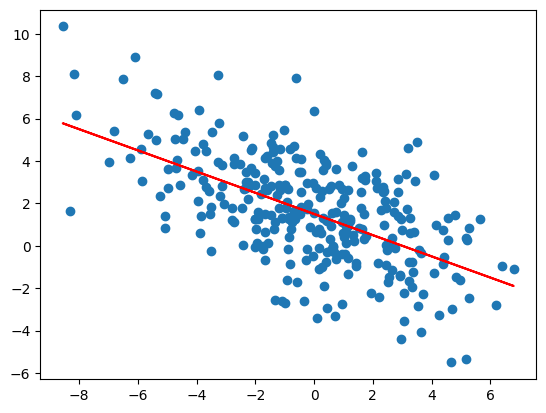

In [5]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 1], y_noise)
plt.plot(X[:, 1], y, color="red")

In [6]:
def regression_coeffs(data):
    x = data[:, :-1]
    y = data[:, -1]
    coef = np.linalg.lstsq(x, y, rcond=None)[0]

    return coef

In [7]:
dataset = np.hstack([X, y_noise[:, np.newaxis]])
dataset

array([[ 1.00000000e+00, -1.10335995e+00, -2.62318714e+00],
       [ 1.00000000e+00,  5.81923257e-01,  2.82600659e+00],
       [ 1.00000000e+00,  1.73131137e+00,  3.10115388e+00],
       [ 1.00000000e+00,  1.62585666e+00,  4.44290314e+00],
       [ 1.00000000e+00, -9.67167348e-01,  1.79594119e+00],
       [ 1.00000000e+00, -4.57779122e+00,  2.87193054e+00],
       [ 1.00000000e+00, -2.01326903e+00,  2.84936458e+00],
       [ 1.00000000e+00,  4.08963372e-01, -7.48239647e-01],
       [ 1.00000000e+00, -1.97990824e+00,  7.74011535e-01],
       [ 1.00000000e+00,  1.01330738e+00,  2.25201634e+00],
       [ 1.00000000e+00,  2.48376432e+00, -1.79101032e-01],
       [ 1.00000000e+00,  3.38042038e+00, -1.21867597e+00],
       [ 1.00000000e+00, -4.37933679e-01,  2.52664513e+00],
       [ 1.00000000e+00,  3.22209187e+00, -7.81165093e-01],
       [ 1.00000000e+00,  1.53429385e-02,  6.33434245e+00],
       [ 1.00000000e+00, -3.69069659e+00,  2.78376441e+00],
       [ 1.00000000e+00, -6.51613166e+00

In [8]:
res = regression_coeffs(dataset)
res

array([ 1.57545378, -0.50689414])

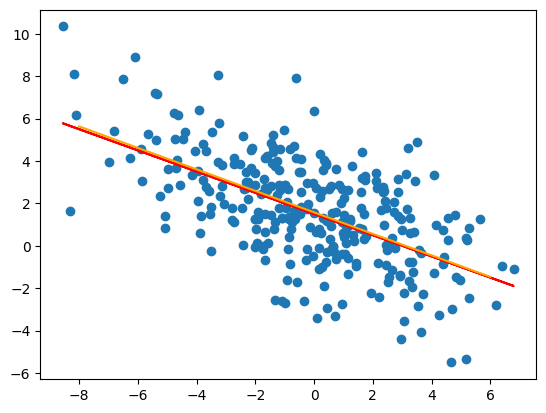

In [9]:
plt.scatter(X[:, 1], y_noise)

test = np.array([[1, -8], [1, 6]])
plt.plot(X[:, 1], y, color="red")
plt.plot(test[:, 1], test @ res, color="orange")

In [12]:
db = DoubleBootstrap(dataset, regression_coeffs)


ci = db.confidence_interval(confidence_level, seed=42, side="two", n_jobs=-1)


In [11]:
print(ci)

lower = [ 1.33803296 -0.59912013], upper = [ 1.82621258 -0.41750916], confidence level = 0.95, side = two
